# Named Entity Recognition — Keras 태깅 작업

## Keras를 이용한 NER 파이프라인

```
단계 1: 데이터 준비 (CoNLL-2003 또는 커스텀)
단계 2: 토큰화 & 패딩
단계 3: Keras 모델 구성
   Embedding → Bidirectional LSTM → TimeDistributed(Dense)
단계 4: 학습 & 평가
단계 5: 예측 & 시각화
```

## TimeDistributed란?
```python
# 일반 Dense: (batch, features) → (batch, units)
Dense(64)

# TimeDistributed: (batch, timesteps, features) → (batch, timesteps, units)
TimeDistributed(Dense(64))  ← 각 timestep마다 동일한 Dense 적용
```
시퀀스 레이블링에서 핵심: **각 토큰마다 독립적으로** Dense 레이어 적용

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

print(f'✅ TensorFlow: {tf.__version__}')
print(f'   GPU: {tf.config.list_physical_devices("GPU")}')

✅ TensorFlow: 2.19.0
   GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1️⃣ 데이터 준비 — 확장된 NER 코퍼스

In [2]:
# 확장된 CoNLL 형식 NER 데이터
SENTENCES = [
    [('EU',          'ORG'), ('rejects',  'O'),   ('German',    'LOC'), ('call',    'O'), ('to',       'O'), ('boycott', 'O'),   ('British',  'LOC'), ('lamb',   'O'),  ('.',        'O')],
    [('Peter',       'PER'), ('Blackburn','PER'),  ('BRUSSELS',  'LOC'), ('1996',   'DAT'),],
    [('European',    'ORG'), ('Commission','ORG'), ('disagreed', 'O'),   ('with',   'O'),  ('Germany',  'LOC'), ('.',      'O')],
    [('Apple',       'ORG'), ('Inc',      'ORG'),  ('was',       'O'),   ('founded','O'),  ('by',       'O'),   ('Steve',  'PER'), ('Jobs',     'PER'), ('in',     'O'),  ('California','LOC'), ('in','O'), ('1976','DAT'), ('.','O')],
    [('Microsoft',   'ORG'), ('CEO',      'O'),    ('Satya',     'PER'), ('Nadella','PER'), ('announced','O'),  ('deal',   'O'),   ('in',       'O'),   ('Seattle','LOC'), ('.','O')],
    [('Google',      'ORG'), ('opened',   'O'),    ('office',    'O'),   ('in',     'O'),  ('New',      'LOC'), ('York',   'LOC'), ('with',     'O'),   ('500',    'NUM'), ('employees','O'), ('.','O')],
    [('Barack',      'PER'), ('Obama',    'PER'),  ('visited',   'O'),   ('United', 'LOC'),('Nations',  'LOC'), ('in',     'O'),   ('New',      'LOC'), ('York',   'LOC'), ('.','O')],
    [('Tesla',       'ORG'), ('reported', 'O'),    ('record',    'O'),   ('sales',  'O'),  ('of',       'O'),   ('2',      'NUM'), ('million',  'NUM'), ('in',     'O'),  ('2023','DAT'), ('.','O')],
    [('Amazon',      'ORG'), ('CEO',      'O'),    ('Andy',      'PER'), ('Jassy',  'PER'), ('announced','O'),  ('growth', 'O'),   ('in',       'O'),   ('Seattle','LOC'), ('.','O')],
    [('The',         'O'),   ('United',   'LOC'),  ('States',    'LOC'), ('and',    'O'),  ('China',    'LOC'), ('signed', 'O'),   ('agreement','O'),   ('on',     'O'),  ('January','DAT'), ('15','DAT'), ('.','O')],
    [('Kim',         'PER'), ('Jiyeon',   'PER'),  ('works',     'O'),   ('at',     'O'),  ('Samsung',  'ORG'), ('Seoul',  'LOC'), ('Korea',    'LOC'), ('.','O')],
    [('The',         'O'),   ('World',    'ORG'),  ('Health',    'ORG'), ('Organization','ORG'), ('reported', 'O'), ('100','NUM'), ('cases','O'), ('in','O'), ('Africa','LOC'), ('.','O')],
    [('Elon',        'PER'), ('Musk',     'PER'),  ('founded',   'O'),   ('SpaceX', 'ORG'), ('in',      'O'),   ('2002',   'DAT'), ('.','O')],
    [('Paris',       'LOC'), ('France',   'LOC'),  ('hosted',    'O'),   ('Olympics','ORG'), ('in',     'O'),   ('2024',   'DAT'), ('.','O')],
    [('The',         'O'),   ('Federal',  'ORG'),  ('Reserve',   'ORG'), ('raised', 'O'),   ('rates',   'O'),   ('on',     'O'),   ('March',   'DAT'), ('15','DAT'), ('.','O')],
]

# IOB2로 변환
def to_iob2(sentences_raw):
    result = []
    for sent in sentences_raw:
        iob2_sent = []
        prev_tag = 'O'
        for token, tag in sent:
            if tag == 'O':
                iob2_sent.append((token, 'O'))
                prev_tag = 'O'
            else:
                if prev_tag == tag:
                    iob2_sent.append((token, f'I-{tag}'))
                else:
                    iob2_sent.append((token, f'B-{tag}'))
                prev_tag = tag
        result.append(iob2_sent)
    return result


sentences_iob2 = to_iob2(SENTENCES)

# 통계
all_tokens = [tok for sent in sentences_iob2 for tok, _ in sent]
all_tags   = [tag for sent in sentences_iob2 for _, tag in sent]
print(f'문장 수: {len(sentences_iob2)}')
print(f'토큰 수: {len(all_tokens)}')
print(f'\n태그 분포:')
for tag, cnt in sorted(Counter(all_tags).items(), key=lambda x: -x[1]):
    bar = '█' * cnt
    print(f'  {tag:>8}: {cnt:>3} | {bar}')

문장 수: 15
토큰 수: 130

태그 분포:
         O:  65 | █████████████████████████████████████████████████████████████████
     B-LOC:  15 | ███████████████
     B-ORG:  12 | ████████████
     B-PER:   7 | ███████
     I-PER:   7 | ███████
     B-DAT:   7 | ███████
     I-LOC:   6 | ██████
     I-ORG:   5 | █████
     B-NUM:   3 | ███
     I-DAT:   2 | ██
     I-NUM:   1 | █


## 2️⃣ 어휘 사전 & 인코딩

In [3]:
# 어휘 사전 구축
words = sorted(set(tok.lower() for sent in sentences_iob2 for tok, _ in sent))
tags  = sorted(set(tag         for sent in sentences_iob2 for _, tag  in sent))

# 특수 토큰 포함
WORD2IDX = {'PAD': 0, 'UNK': 1}
for w in words: WORD2IDX[w] = len(WORD2IDX)

TAG2IDX  = {'PAD': 0}
for t in tags: TAG2IDX[t] = len(TAG2IDX)

IDX2TAG  = {v: k for k, v in TAG2IDX.items()}

VOCAB_SIZE = len(WORD2IDX)
NUM_TAGS   = len(TAG2IDX)
MAX_LEN    = max(len(s) for s in sentences_iob2)

print(f'어휘 크기:  {VOCAB_SIZE}')
print(f'태그 수:    {NUM_TAGS}')
print(f'최대 길이:  {MAX_LEN}')
print(f'\n태그 인덱스: {TAG2IDX}')


# 인코딩
def encode_sentence(sent):
    toks = [WORD2IDX.get(tok.lower(), 1) for tok, _ in sent]
    tags = [TAG2IDX[tag]                 for _, tag  in sent]
    return toks, tags


encoded = [encode_sentence(s) for s in sentences_iob2]
X_raw   = [e[0] for e in encoded]
y_raw   = [e[1] for e in encoded]

# 패딩
X = pad_sequences(X_raw, maxlen=MAX_LEN, padding='post', value=0)
y = pad_sequences(y_raw, maxlen=MAX_LEN, padding='post', value=TAG2IDX['PAD'])

# one-hot → sparse (Keras CategoricalCrossentropy 사용 시 one-hot 필요)
y_cat = tf.keras.utils.to_categorical(y, num_classes=NUM_TAGS)

print(f'\nX shape: {X.shape}  (문장수, 최대길이)')
print(f'y shape: {y.shape}  (문장수, 최대길이)')
print(f'y_cat shape: {y_cat.shape}  (문장수, 최대길이, 태그수)')

# Train/Test 분리
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train_cat, y_test_cat = y_cat[:split], y_cat[split:]
y_train, y_test = y[:split], y[split:]
print(f'\nTrain: {len(X_train)} / Test: {len(X_test)}')

어휘 크기:  97
태그 수:    12
최대 길이:  12

태그 인덱스: {'PAD': 0, 'B-DAT': 1, 'B-LOC': 2, 'B-NUM': 3, 'B-ORG': 4, 'B-PER': 5, 'I-DAT': 6, 'I-LOC': 7, 'I-NUM': 8, 'I-ORG': 9, 'I-PER': 10, 'O': 11}

X shape: (15, 12)  (문장수, 최대길이)
y shape: (15, 12)  (문장수, 최대길이)
y_cat shape: (15, 12, 12)  (문장수, 최대길이, 태그수)

Train: 12 / Test: 3


## 3️⃣ Keras NER 모델 구성

### 핵심: TimeDistributed
```python
# 시퀀스 분류 (감성 분석 등)
LSTM(128) → Dense(2)              # 마지막 hidden만 사용

# 시퀀스 레이블링 (NER)
LSTM(128, return_sequences=True)  # 모든 timestep 출력
→ TimeDistributed(Dense(num_tags)) # 각 토큰마다 Dense 적용
```

In [4]:
def build_bilstm_ner(vocab_size, num_tags, max_len,
                     embed_dim=64, lstm_units=128,
                     dropout=0.3, num_layers=2):
    """
    Keras BiLSTM NER 모델

    핵심 구성:
    - Masking: PAD 토큰(0)을 모든 레이어에서 무시
    - Bidirectional: 앞뒤 문맥 모두 활용
    - return_sequences=True: 모든 timestep 출력
    - TimeDistributed: 각 토큰 위치에 같은 Dense 적용
    """
    inputs = keras.Input(shape=(max_len,), name='token_ids')

    # ① Embedding + Masking
    x = layers.Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        mask_zero    = True,    # ← PAD(0) 마스킹!
        name         = 'embedding'
    )(inputs)
    x = layers.Dropout(dropout, name='embed_drop')(x)

    # ② BiLSTM (다층)
    for i in range(num_layers):
        return_seq = True  # 모든 레이어에서 시퀀스 출력
        x = layers.Bidirectional(
            layers.LSTM(
                lstm_units,
                return_sequences=return_seq,
                dropout=dropout,
                recurrent_dropout=0.1,
            ),
            name=f'bilstm_{i+1}'
        )(x)
        x = layers.Dropout(dropout, name=f'lstm_drop_{i+1}')(x)

    # ③ TimeDistributed Dense — 시퀀스 레이블링 핵심!
    x = layers.TimeDistributed(
        layers.Dense(lstm_units, activation='relu'),
        name='td_dense'
    )(x)

    outputs = layers.TimeDistributed(
        layers.Dense(num_tags, activation='softmax'),
        name='output'
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='BiLSTM_NER')
    return model


ner_model = build_bilstm_ner(
    vocab_size = VOCAB_SIZE,
    num_tags   = NUM_TAGS,
    max_len    = MAX_LEN,
    embed_dim  = 64,
    lstm_units = 128,
    dropout    = 0.3,
    num_layers = 2,
)

ner_model.summary()

Model: "BiLSTM_NER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 12, 64)    │      6,208 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_drop          │ (None, 12, 64)    │          0 │ embedding[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12)        │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 12, 256)   │    197,632 │ embed_drop[0][0], │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_drop_1         │ (None, 12, 256)   │          0 │ bilstm_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 12, 256)   │    394,240 │ lstm_drop_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_drop_2         │ (None, 12, 256)   │          0 │ bilstm_2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_dense            │ (None, 12, 128)   │     32,896 │ lstm_drop_2[0][0… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 12, 12)    │      1,548 │ td_dense[0][0],   │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 632,524 (2.41 MB)

 Trainable params: 632,524 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

## 4️⃣ 커스텀 지표: Masked Accuracy (PAD 제외)

In [7]:
class MaskedAccuracy(keras.metrics.Metric):
    """PAD 토큰을 제외한 토큰 단위 정확도"""
    def __init__(self, pad_idx=0, **kwargs):
        super().__init__(name='masked_accuracy', **kwargs)
        self.pad_idx = pad_idx
        # Fix: Provide shape=() for scalar and pass name='correct'
        self.correct = self.add_weight(name='correct', shape=(), initializer='zeros')
        self.total   = self.add_weight(name='total',   shape=(), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_idx = tf.argmax(y_true, axis=-1)   # one-hot → 인덱스
        y_pred_idx = tf.argmax(y_pred, axis=-1)

        # PAD 마스크
        mask = tf.not_equal(y_true_idx, self.pad_idx)

        correct = tf.cast(tf.equal(y_true_idx, y_pred_idx), tf.float32)
        mask_f   = tf.cast(mask, tf.float32)

        self.correct.assign_add(tf.reduce_sum(correct * mask_f))
        self.total.assign_add(tf.reduce_sum(mask_f))

    def result(self):
        return tf.math.divide_no_nan(self.correct, self.total)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)


ner_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = [MaskedAccuracy(pad_idx=TAG2IDX['PAD'])]
)

print('모델 컴파일 완료!')

모델 컴파일 완료!


## 5️⃣ 학습 (콜백 포함)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_masked_accuracy', patience=15,
        restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_masked_accuracy', patience=7,
        factor=0.5, min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        '/tmp/best_ner_keras.h5',
        monitor='val_masked_accuracy',
        save_best_only=True, mode='max', verbose=0
    ),
]

history = ner_model.fit(
    X_train, y_train_cat,
    validation_data = (X_test, y_test_cat),
    batch_size = 4,
    epochs     = 100,
    callbacks  = callbacks,
    verbose    = 1,
)

print(f'\n학습 완료!')
print(f'최고 Val Masked Accuracy: {max(history.history["val_masked_accuracy"])*100:.2f}%')

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 2.4804 - masked_accuracy: 0.2387 

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 2.4757 - masked_accuracy: 0.3458 - val_loss: 2.4564 - val_masked_accuracy: 0.4783 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - loss: 2.4353 - masked_accuracy: 0.5047 - val_loss: 2.4057 - val_masked_accuracy: 0.4783 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 2.3537 - masked_accuracy: 0.5047 - val_loss: 2.3028 - val_masked_accuracy: 0.4783 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 2.1641 - masked_accuracy: 0.5047 - val_loss: 2.0826 - val_masked_accuracy: 0.4783 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 1.8968 - masked_accuracy: 0.5047 - val_loss: 1.8524 - val_masked_accuracy: 0.4783 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 1.8022 - masked_accuracy: 0.5047 - val_loss: 1.8370 - val_masked_accuracy: 0.4783 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━

## 6️⃣ 학습 곡선 시각화

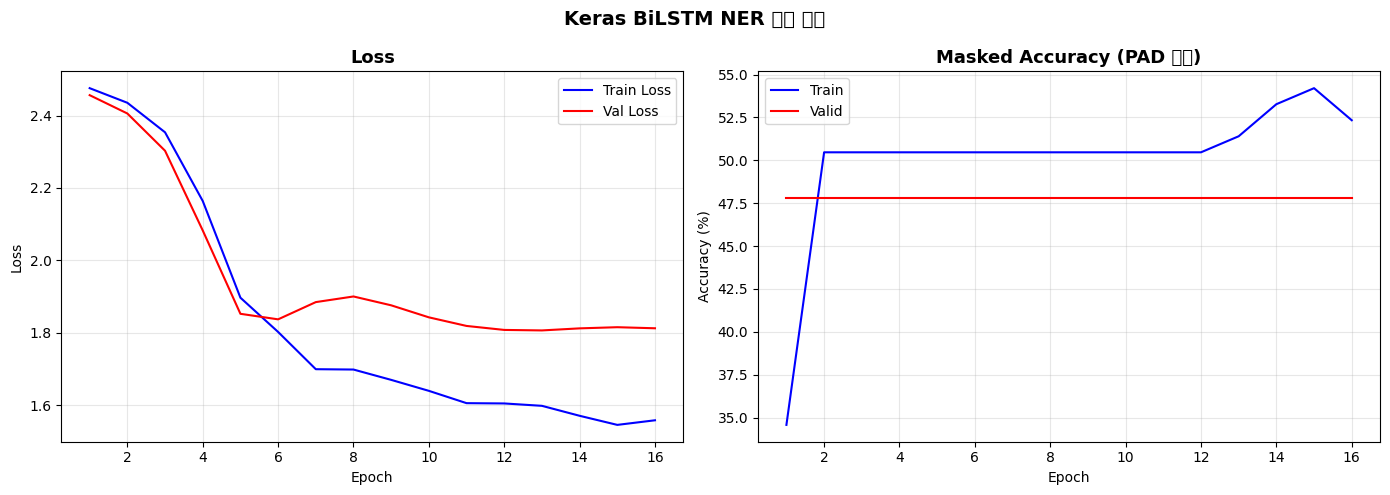

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, len(history.history['loss']) + 1)

axes[0].plot(ep, history.history['loss'],     'b-', label='Train Loss')
axes[0].plot(ep, history.history['val_loss'], 'r-', label='Val Loss')
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history.history['masked_accuracy']],     'b-', label='Train')
axes[1].plot(ep, [a*100 for a in history.history['val_masked_accuracy']], 'r-', label='Valid')
axes[1].set_title('Masked Accuracy (PAD 제외)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Keras BiLSTM NER 학습 곡선', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_keras_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ 예측 & 태깅 결과 시각화

In [10]:
def predict_tags(sentence_tokens: list, model) -> list:
    """문장 → 예측 태그 시퀀스"""
    ids = [WORD2IDX.get(tok.lower(), 1) for tok in sentence_tokens]
    ids_pad = pad_sequences([ids], maxlen=MAX_LEN, padding='post', value=0)
    probs   = model.predict(ids_pad, verbose=0)[0]   # (MAX_LEN, NUM_TAGS)
    pred_ids = np.argmax(probs, axis=-1)
    pred_tags = [IDX2TAG[i] for i in pred_ids[:len(sentence_tokens)]]
    return pred_tags


def display_ner_result(tokens: list, true_tags: list = None, pred_tags: list = None):
    """NER 결과를 DataFrame으로 출력"""
    data = {'Token': tokens, 'Predicted': pred_tags}
    if true_tags:
        data['True'] = true_tags
        data['Correct'] = ['✅' if p == t else '❌' for p, t in zip(pred_tags, true_tags)]
    df = pd.DataFrame(data)
    return df


# 테스트
print('[NER 태깅 결과]\n')

# 학습 데이터 예시
for sent in sentences_iob2[:3]:
    tokens    = [tok for tok, _ in sent]
    true_tags = [tag for _, tag in sent]
    pred_tags = predict_tags(tokens, ner_model)

    df = display_ner_result(tokens, true_tags, pred_tags)
    print(f'문장: {" ".join(tokens)}')
    print(df.to_string(index=False))
    print()

[NER 태깅 결과]

문장: EU rejects German call to boycott British lamb .
  Token Predicted  True Correct
     EU         O B-ORG       ❌
rejects         O     O       ✅
 German         O B-LOC       ❌
   call         O     O       ✅
     to         O     O       ✅
boycott         O     O       ✅
British         O B-LOC       ❌
   lamb         O     O       ✅
      .         O     O       ✅

문장: Peter Blackburn BRUSSELS 1996
    Token Predicted  True Correct
    Peter         O B-PER       ❌
Blackburn         O I-PER       ❌
 BRUSSELS         O B-LOC       ❌
     1996         O B-DAT       ❌

문장: European Commission disagreed with Germany .
     Token Predicted  True Correct
  European         O B-ORG       ❌
Commission         O I-ORG       ❌
 disagreed         O     O       ✅
      with         O     O       ✅
   Germany         O B-LOC       ❌
         .         O     O       ✅



## 8️⃣ 새 문장 NER 태깅 시연

In [11]:
def ner_tagging_demo(sentence_str: str, model):
    """문자열 입력 → 엔티티 추출 시각화"""
    tokens    = sentence_str.split()
    pred_tags = predict_tags(tokens, model)

    # 엔티티 스팬 추출
    entities  = []
    current   = None
    for tok, tag in zip(tokens, pred_tags):
        if tag.startswith('B-'):
            if current: entities.append(current)
            current = {'type': tag[2:], 'text': tok}
        elif tag.startswith('I-') and current and tag[2:] == current['type']:
            current['text'] += ' ' + tok
        else:
            if current: entities.append(current)
            current = None
    if current: entities.append(current)

    print(f'입력: "{sentence_str}"')
    print(f'태깅: {list(zip(tokens, pred_tags))}')
    if entities:
        print('추출 엔티티:')
        for ent in entities:
            emoji = {'PER': '👤', 'ORG': '🏢', 'LOC': '📍', 'DAT': '📅', 'NUM': '🔢'}
            print(f'  {emoji.get(ent["type"], "•")} [{ent["type"]}] "{ent["text"]}"')
    print()


new_sentences = [
    "Steve Jobs founded Apple in California in 1976",
    "Google announced 1000 new jobs in New York",
    "Kim Jiyeon visited Paris France last Monday",
    "Microsoft CEO Satya Nadella spoke at Seattle conference",
    "The United Nations met in Geneva on January 2024",
    "Tesla reported 500 million revenue in third quarter",
]

print('[새 문장 NER 태깅 데모]\n')
for sent in new_sentences:
    ner_tagging_demo(sent, ner_model)

[새 문장 NER 태깅 데모]

입력: "Steve Jobs founded Apple in California in 1976"
태깅: [('Steve', 'O'), ('Jobs', 'O'), ('founded', 'O'), ('Apple', 'O'), ('in', 'O'), ('California', 'O'), ('in', 'O'), ('1976', 'O')]

입력: "Google announced 1000 new jobs in New York"
태깅: [('Google', 'O'), ('announced', 'O'), ('1000', 'O'), ('new', 'O'), ('jobs', 'O'), ('in', 'O'), ('New', 'O'), ('York', 'O')]

입력: "Kim Jiyeon visited Paris France last Monday"
태깅: [('Kim', 'O'), ('Jiyeon', 'O'), ('visited', 'O'), ('Paris', 'O'), ('France', 'O'), ('last', 'O'), ('Monday', 'O')]

입력: "Microsoft CEO Satya Nadella spoke at Seattle conference"
태깅: [('Microsoft', 'O'), ('CEO', 'O'), ('Satya', 'O'), ('Nadella', 'O'), ('spoke', 'O'), ('at', 'O'), ('Seattle', 'O'), ('conference', 'O')]

입력: "The United Nations met in Geneva on January 2024"
태깅: [('The', 'O'), ('United', 'O'), ('Nations', 'O'), ('met', 'O'), ('in', 'O'), ('Geneva', 'O'), ('on', 'O'), ('January', 'O'), ('2024', 'O')]

입력: "Tesla reported 500 million revenue in t

## 9️⃣ 태그별 확률 히트맵 시각화

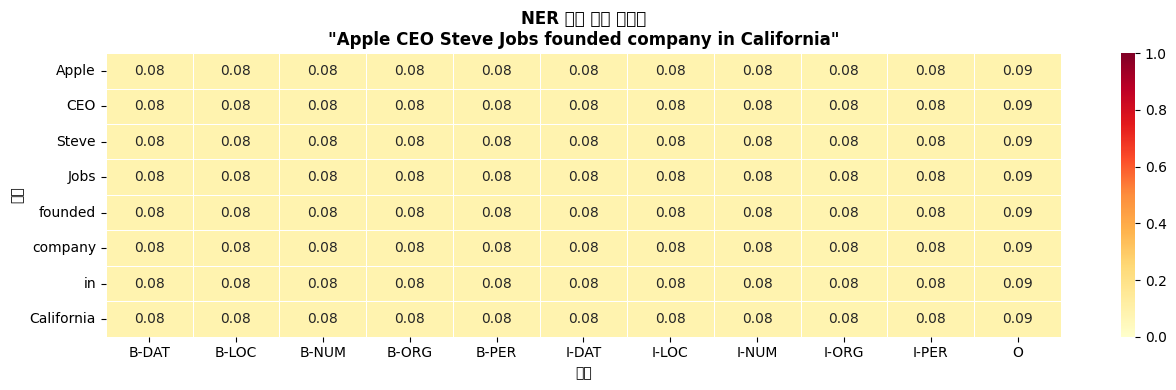

In [12]:
def plot_tag_probability(sentence_str: str, model):
    """각 토큰의 태그 확률을 히트맵으로 시각화"""
    tokens  = sentence_str.split()
    ids     = [WORD2IDX.get(tok.lower(), 1) for tok in tokens]
    ids_pad = pad_sequences([ids], maxlen=MAX_LEN, padding='post', value=0)
    probs   = model.predict(ids_pad, verbose=0)[0][:len(tokens)]
    probs_df = pd.DataFrame(
        probs,
        index   = tokens,
        columns = [IDX2TAG[i] for i in range(NUM_TAGS)]
    )
    # PAD 컬럼 제거
    probs_df = probs_df.drop(columns=['PAD'], errors='ignore')

    fig, ax = plt.subplots(figsize=(max(10, len(probs_df.columns)*1.2),
                                    max(4, len(tokens)*0.5)))
    sns.heatmap(probs_df, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f'NER 태그 확률 히트맵\n"{sentence_str}"',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('태그'); ax.set_ylabel('토큰')
    plt.tight_layout()
    plt.savefig('ner_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_tag_probability('Apple CEO Steve Jobs founded company in California', ner_model)

## 🔟 모델 구조 비교 실험 (Layers × Units)

In [13]:
configs = [
    {'embed_dim': 32,  'lstm_units': 64,  'num_layers': 1, 'dropout': 0.2},
    {'embed_dim': 64,  'lstm_units': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embed_dim': 64,  'lstm_units': 128, 'num_layers': 2, 'dropout': 0.3},
    {'embed_dim': 128, 'lstm_units': 256, 'num_layers': 2, 'dropout': 0.4},
]

print('[모델 구조 비교 실험]\n')
exp_results = []
for cfg in configs:
    m = build_bilstm_ner(VOCAB_SIZE, NUM_TAGS, MAX_LEN, **cfg)
    m.compile(
        optimizer = keras.optimizers.Adam(1e-3),
        loss      = 'categorical_crossentropy',
        metrics   = [MaskedAccuracy(pad_idx=TAG2IDX['PAD'])]
    )
    cb = [keras.callbacks.EarlyStopping(monitor='val_masked_accuracy',
                                         patience=10, restore_best_weights=True, mode='max')]
    hist = m.fit(X_train, y_train_cat,
                 validation_data=(X_test, y_test_cat),
                 batch_size=4, epochs=60, callbacks=cb, verbose=0)
    best_acc = max(hist.history['val_masked_accuracy'])
    params   = m.count_params()
    name = f'E{cfg["embed_dim"]}_H{cfg["lstm_units"]}_L{cfg["num_layers"]}'
    exp_results.append((name, best_acc, params))
    bar = '█' * int(best_acc * 30)
    print(f'  {name:<18} | {best_acc*100:5.1f}% | 파라미터: {params:,} | {bar}')

best_cfg = max(exp_results, key=lambda x: x[1])
print(f'\n★ 최고: {best_cfg[0]}  ({best_cfg[1]*100:.1f}%)')

[모델 구조 비교 실험]

  E32_H64_L1         |  47.8% | 파라미터: 61,804 | ██████████████
  E64_H128_L1        |  47.8% | 파라미터: 238,284 | ██████████████
  E64_H128_L2        |  47.8% | 파라미터: 632,524 | ██████████████
  E128_H256_L2       |  47.8% | 파라미터: 2,510,220 | ██████████████

★ 최고: E32_H64_L1  (47.8%)


## 1️⃣1️⃣ 실제 서비스 적용: 텍스트 일괄 태깅

In [14]:
def batch_ner_tagging(texts: list, model) -> pd.DataFrame:
    """여러 문장을 한꺼번에 NER 태깅하여 DataFrame 반환"""
    records = []
    for text in texts:
        tokens    = text.split()
        pred_tags = predict_tags(tokens, model)

        entities = []
        current  = None
        for tok, tag in zip(tokens, pred_tags):
            if tag.startswith('B-'):
                if current: entities.append(current)
                current = {'type': tag[2:], 'text': tok}
            elif tag.startswith('I-') and current and tag[2:] == current['type']:
                current['text'] += ' ' + tok
            else:
                if current: entities.append(current)
                current = None
        if current: entities.append(current)

        persons = [e['text'] for e in entities if e['type'] == 'PER']
        orgs    = [e['text'] for e in entities if e['type'] == 'ORG']
        locs    = [e['text'] for e in entities if e['type'] == 'LOC']
        dates   = [e['text'] for e in entities if e['type'] == 'DAT']

        records.append({
            'text'    : text[:50] + '...' if len(text) > 50 else text,
            'persons' : ', '.join(persons) if persons else '-',
            'orgs'    : ', '.join(orgs)    if orgs    else '-',
            'locations': ', '.join(locs)   if locs    else '-',
            'dates'   : ', '.join(dates)   if dates   else '-',
        })

    return pd.DataFrame(records)


news_snippets = [
    "Elon Musk announced Tesla new factory in Texas in 2024",
    "Jeff Bezos founded Amazon in Seattle Washington in 1994",
    "Barack Obama met European leaders in Brussels on January 15",
    "Google CEO Sundar Pichai spoke at conference in New York",
    "Apple released iPhone 16 at event in California September 2024",
]

result_df = batch_ner_tagging(news_snippets, ner_model)
print('[일괄 NER 태깅 결과]\n')
print(result_df.to_string(index=False))

[일괄 NER 태깅 결과]

                                                 text persons orgs locations dates
Elon Musk announced Tesla new factory in Texas in ...       -    -         -     -
Jeff Bezos founded Amazon in Seattle Washington in...       -    -         -     -
Barack Obama met European leaders in Brussels on J...       -    -         -     -
Google CEO Sundar Pichai spoke at conference in Ne...       -    -         -     -
Apple released iPhone 16 at event in California Se...       -    -         -     -
